In [1]:
# Import Libraries
import time
import sys
import gc
import fitsio
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from scipy.interpolate import interp1d
from desimodel.footprint import is_point_in_desi
import MockCode as mc
import catalogue_analysis as ca
from cosmology import cosmo



In [2]:
#Set configuration parameters:
#Including:  Whether full Uuchu is read (needs parallel environment) or just pre-made fits subsample

# Configure
date='28thAug'
reg='N'                    #North or South. rancat needs to have been produced for the same region. Consistency is checked
Sel=ca.selection(reg)      #Defines magnitude limits etc for this region

obs_seed= 123
sig_lgv = 0.02
min_Vpeak=70.0       #Discard all halos with Vpeak<min_Vpeak. This limits the redshift below which the mock is complete  
N_neigh_vpeak = 1000 #with 1000 the logVpeak scatter among neighbours is < 10^-6 and so will introduce no more than 10^-5 scatter in the magnitude relation


#rancat=rf'./sdata/Mocks/input_rancat_{reg}0.fits'   #random catalogue to which the matching is made. It was made by RandomCatalogue.ipynb 
rancat=rf'./sdata/Mocks/rancat{date}_fordata_{reg}.fits'
subhalo_fits=rf'./sdata/Mocks/subhalos_{reg}_{min_Vpeak:.1f}_seed{obs_seed:3d}_sig_lgv{sig_lgv:.2f}_N_neigh_vpeak{N_neigh_vpeak:4d}.fits'     #file to store a fits version of the selected part of uuchu. If already exists set readfulluuchu=False
mockcat=rf'./sdata/Mocks/mock_{reg}_seed{obs_seed:3d}_sig_lgv{sig_lgv:.2f}.fits'#file to store resulting mock catalogue
randoms_out=rf'./sdata/Mocks/randoms_formock_{reg}.fits' #output random catalogue matching the sky footprint of the output mock



print('Output Checkpoint file:', subhalo_fits)
print('Output Mock catalogue file:', mockcat)
print('Input random catalogue file:', rancat)
print('Output random catalogue file:', randoms_out)


readfulluuchu = False  # If checkpoint file exists and you are not changing obs_seed, sig_lgv, N_neigh_peak or min_Vpeak then this can be set to False and it will run faster and on a login node
lbox=2000.0           #Box size of Uuchu simulation [0,lbox]
frac_box=0.8     # We cut a sphere of rsphere= frac_box*lbox from 2x2x2 replicas of the simulation cube
rsphere=lbox*frac_box # radius of comoving sphere we cut from the simulation and within which we create the mock  
RAmin = 120          #Region of sky within which we limit the mock.  These cuts are applied before saving subhalo_fits so should not be changed if reusing that dataset.
RAmax = 300
DECmin = 0
DECmax = 90
nzbins=100         #number of redshift windows
N_neigh=50      #Number of neighbours used to define secondary rank used in colour matching
usemask= True   #use official DR2 mask from the following file
tiles_file = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/tiles-BRIGHT.fits'
verbose_stats = False # If true the stats of the subhalo astro-py table are output after every stage
rancat_out = False  #don't bother outputting a random catalogue  (one version can suffice fro all random seeds and many parameter changes)

Output Checkpoint file: ./sdata/Mocks/subhalos_N_70.0_seed123_sig_lgv0.02_N_neigh_vpeak1000.fits
Output Mock catalogue file: ./sdata/Mocks/mock_N_seed123_sig_lgv0.02.fits
Input random catalogue file: ./sdata/Mocks/rancat28thAug_fordata_N.fits
Output random catalogue file: ./sdata/Mocks/randoms_formock_N.fits


In [3]:
#Read the previously saved fits file of the selected sample rather than rereading all of Uuchu
if not readfulluuchu:
    start_time = time.time()
    subhalos=Table.read(subhalo_fits)
    end_time = time.time()
    print(f"time to read saved pre-sorted Uuchu subhalos from fits file: {end_time - start_time:.1f} seconds")
    assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
    assert RAmin >= subhalos.meta['RAMIN'], f"RAmin limits not compatible: {RAmin} < {subhalos.meta['RAMIN']}"
    assert DECmax <= subhalos.meta['DECMAX'], f"DECmax limits not compatible: {DECmax} > {subhalos.meta['DECMAX']}"
    assert DECmin >= subhalos.meta['DECMIN'], f"DECmmin limits not compatible: {DECmin} < {subhalos.meta['DECMIN']}"
    assert RAmax <= subhalos.meta['RAMAX'], f"RAmax limits not compatible: {RAmax} > {subhalos.meta['RAMAX']}"
    assert min_Vpeak >= subhalos.meta['min_Vpeak'], f"min_Vpeak limits not compatible: {min_Vpeak} < {subhalos.meta['min_Vpeak']}"
    

time to read saved pre-sorted Uuchu subhalos from fits file: 1.9 seconds


In [4]:
#  Read full Uchuu suhbalo catalogue
if readfulluuchu:
    start_time = time.time()
    # Read a sample of the Uuchu subhalos
    index=45 # select redshift snapshot
    redshift = mc.redshift_table[index]

    #Choose random position for observer with seed offset from that used for observer direction
    offset=58
    rng = np.random.default_rng((obs_seed+offset))
    xobs = lbox * rng.random()
    yobs = lbox * rng.random()
    zobs = lbox * rng.random()
    print('Observer position:',xobs,yobs,zobs)
    
    # Define the directory containing the halo files
    print("Reading Uuchu data for redshift:",redshift)
    halodir = f"/global/cfs/cdirs/desi/mocks/cai/Uchuu-SHAM/Uchuu-halo-catalogs/halodir_{index:03d}"
    # List all the halo file
    halolist_files = sorted(glob.glob(f'{halodir}/halolist_*.h5'))

    print("number of files to read:",len(halolist_files))

    subhalos = mc.read_halolist_parallel(halolist_files, randseed=0,  columns=('id', 'pid', 'Mvir_all', 'Vpeak', 'x','y','z','vx','vy','vz','Mpeak_Scale', 'Rvir','rs'), 
                                      min_logMvir=9.0, min_Vpeak=min_Vpeak, lbox=lbox, frac_box=frac_box, xobs=xobs, yobs=yobs, zobs=zobs)
    end_time = time.time()
    print(f"time to read Uuchu from disk: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')


In [5]:
if readfulluuchu:
    print("A quick look at the data types of the subhalos table before we add RA, DEC and redshift:")
    for k in subhalos.colnames:
        print(k, subhalos[k].dtype)
        
    start_time = time.time()

    #Generate random Euler angle and corresponding rotation matrix
    phi, theta, psi = mc.random_euler_angles(seed=obs_seed)
    print("Euler angles:",phi,theta,psi)
    R = mc.euler_rotation_matrix(phi, theta, psi)
    #Rotate the velocities
    vxr = R[0,0]*subhalos['vx'] + R[0,1]*subhalos['vy'] + R[0,2]*subhalos['vz']
    vyr = R[1,0]*subhalos['vx'] + R[1,1]*subhalos['vy'] + R[1,2]*subhalos['vz']
    vzr = R[2,0]*subhalos['vx'] + R[2,1]*subhalos['vy'] + R[2,2]*subhalos['vz']
    #Overwrite originals and delete temporary arrays    
    subhalos['vx'] = vxr
    subhalos['vy'] = vyr
    subhalos['vz'] = vzr
    del vxr,vyr,vzr
    
                                  
    #Rotate positions 
    xr = R[0,0]*subhalos['x'] + R[0,1]*subhalos['y'] + R[0,2]*subhalos['z']
    yr = R[1,0]*subhalos['x'] + R[1,1]*subhalos['y'] + R[1,2]*subhalos['z']
    zr = R[2,0]*subhalos['x'] + R[2,1]*subhalos['y'] + R[2,2]*subhalos['z']
    #Overwrite originals and delete temporary arrays    
    subhalos['x'] = xr
    subhalos['y'] = yr
    subhalos['z'] = zr
    del xr,yr,zr

    
    end_time = time.time()
    print(f"time to rotate coordinates: {end_time - start_time:.1f} seconds")

    start_time = time.time()
        
    # Compute RA DEC and redshift
    subhalos['dist']= np.sqrt( (subhalos['x'])**2 + (subhalos['y'])**2 + (subhalos['z'])**2 ) #distance from observer at origin of original box
    subhalos['DEC']= np.degrees(np.arcsin((subhalos['z'])/subhalos['dist']))
    subhalos['RA'] = np.degrees(np.arctan2((subhalos['y']), (subhalos['x']))) % 360


    # compute radial velocity over speed of light
    c=299792.458  # speed of light in km/s
    vr_c=( subhalos['x']*subhalos['vx'] + subhalos['y']*subhalos['vy'] + subhalos['z']*subhalos['vz'] ) / (c*subhalos['dist'])

    #Free up space by deleting velocities
    subhalos.remove_column('vx')
    subhalos.remove_column('vy')
    subhalos.remove_column('vz')
    gc.collect() #garbage collection

    #Compute concentration
    subhalos['conc']=subhalos['Rvir']/subhalos['rs']

    #Free up space
    subhalos.remove_column('Rvir')
    subhalos.remove_column('rs')
    gc.collect() #garbage collection

    
    #First build lookup table between comoving distance and redshift
    z_grid = np.linspace(0.0, 1.0, 10000)
    Dc_grid = ca.cosmo.comoving_distance(z_grid).value  # Mpc/h

    z_of_Dc = interp1d(
        Dc_grid,
        z_grid,
        bounds_error=False,
        fill_value="extrapolate"
    )
    subhalos['Zu'] = z_of_Dc(subhalos['dist'])

    subhalos['Zobs'] = (1.0+subhalos['Zu'])*(1.0+vr_c) -1.0
    
    subhalos.rename_column('id', 'ID')
    del z_grid,Dc_grid,z_of_Dc,vr_c
    end_time = time.time()
    print(f"time to compute RA, DEC and redshift: {end_time - start_time:.1f} seconds")
    
if verbose_stats: subhalos.info("stats")

In [6]:
# Sort the subhalo table in decreasing order of Vpeak.
# Define the secondary matching variable FracZpeak with respect to neighbours in Vpeak.
# Add scatter to Vpeak and resort
# set up column 'i1' giving the rank in this ordered table and
# define a column 'keep' if above a distance dependent Vpeak cut    
if readfulluuchu:
    start_time = time.time()
    subhalos= mc.make_all_columns_contiguous(subhalos)
    end_time = time.time()
    print(f"time to make subhalos contiguous: {end_time - start_time:.1f} seconds")
    subhalos=mc.pre_sort_subhalos(subhalos,N_neigh=N_neigh_vpeak,sig_lgv=sig_lgv)  
    if verbose_stats: subhalos.info('stats')

In [7]:
if readfulluuchu:
    start_time = time.time()
    # Reduce the size of the subhalo table by removing the objects with subhalos['keep']=False. Also deletes the 'keep' column
    subhalos = mc.filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
    gc.collect() #garbage collection
    end_time = time.time()
    print(f"time to apply vpeak(distance) cut: {end_time - start_time:.1f} seconds")
    if verbose_stats: subhalos.info('stats')

In [8]:
# Cut to an RA DEC patch or to a mask made to match the DESI data to have a small sample for tests
if usemask:
    tiles = fitsio.read(tiles_file) #read the official tiles/mask file
    if (reg=='N'):
        mask = is_point_in_desi(tiles, subhalos['RA'], subhalos['DEC']) # in whole of official DESI DR2 mask
        mask = mask & (subhalos['RA']>85.0) & (subhalos['RA']<305.0) &  (subhalos['DEC']>32.375) #cut to portion in region North
    else:    
        mask = (subhalos['RA']>85.0) & (subhalos['RA']<305.0) &  (subhalos['DEC']>32.375) # region that includes DESI North and none of DESI South
        mask = ~mask & is_point_in_desi(tiles, subhalos['RA'], subhalos['DEC']) # in whole of official DESI DR2 mask but with ~mask excludes the North
    subhalos= subhalos[mask]
    del mask,tiles

    
else:
    start_time = time.time()
    subhalos["keep"]= (subhalos["RA"]>RAmin)  & (subhalos["RA"]<RAmax) & (subhalos["DEC"]>DECmin)  & (subhalos["DEC"]<DECmax) 
    subhalos = mc.filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')
    end_time = time.time()
    print(f"time to apply RA DEC selection: {end_time - start_time:.1f} seconds")


if verbose_stats: subhalos.info("stats")

Uuchu number and box size: 8387798 2000.0


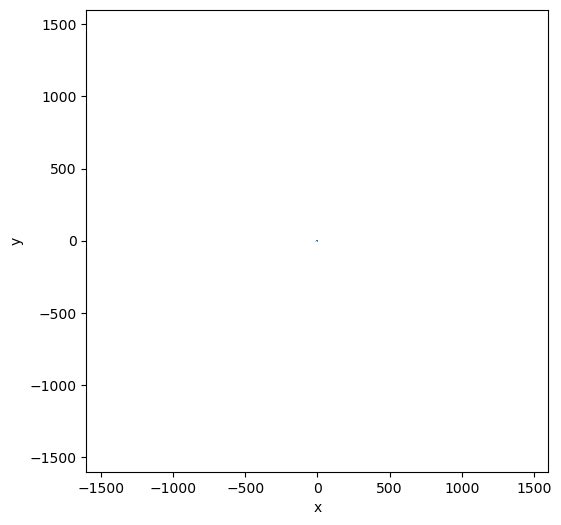

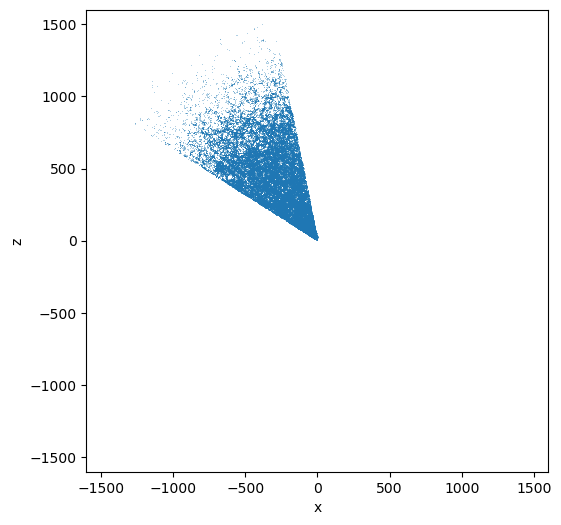

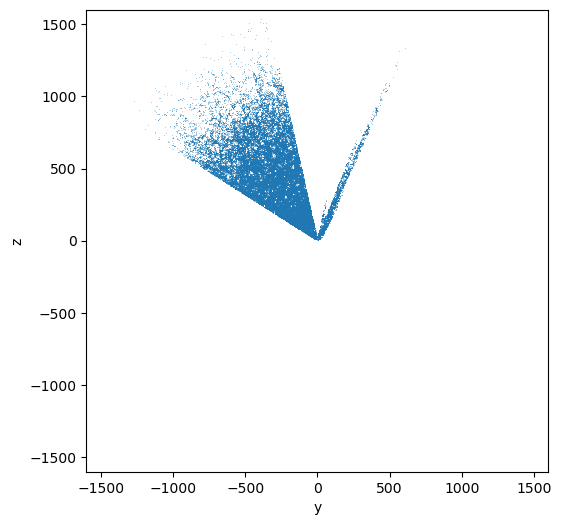

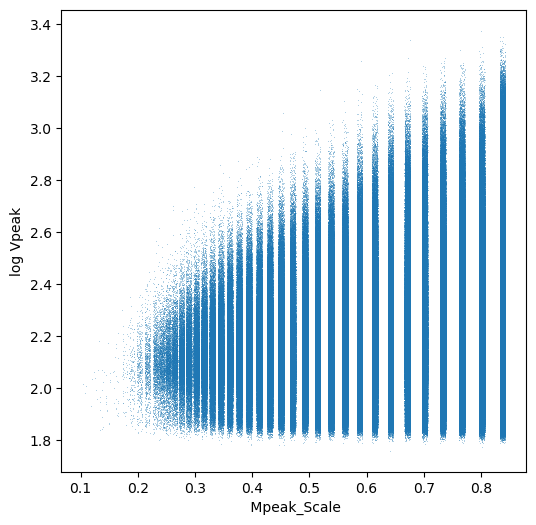

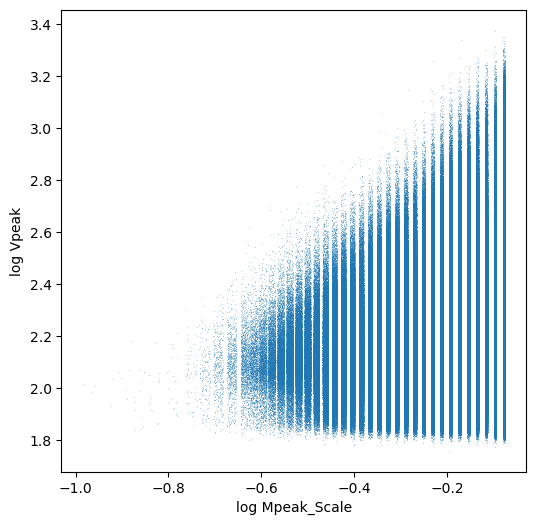

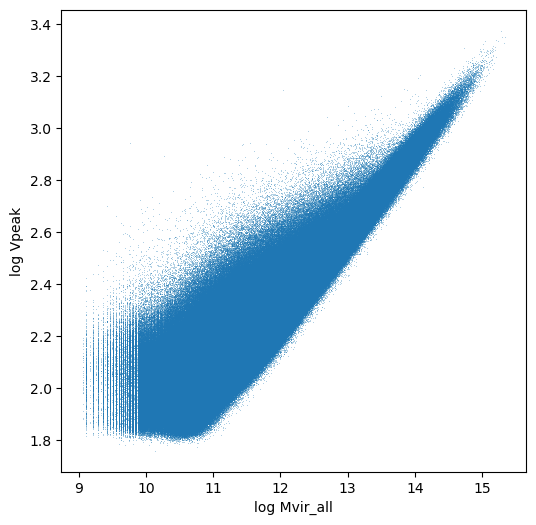

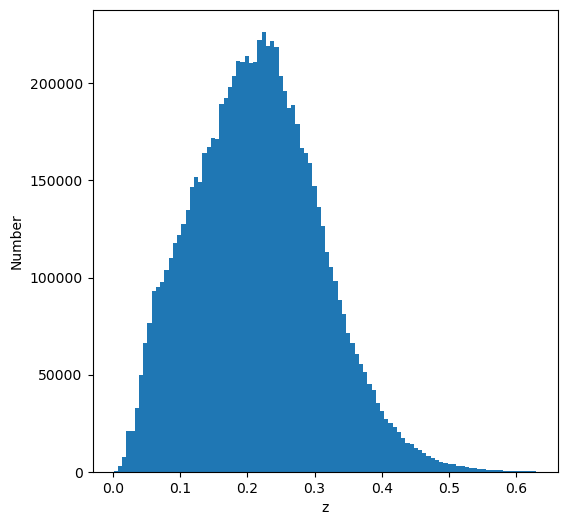

In [9]:
# Inspect uuchu dataset and define the redshift,RA, DEC and other parameters that we may use in matching



nbox=len(subhalos)
print('Uuchu number and box size:',nbox,lbox)



fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['z'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['y'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['y'])<10.0)
ax.scatter(subhalos['x'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
mask = (np.absolute(subhalos['x'])<10.0)
ax.scatter(subhalos['y'][mask],subhalos['z'][mask],marker='.',lw=0,s=0.5)
ax.set_xlabel('y')
ax.set_ylabel('z')
ax.set_xlim(-1600,1600)
ax.set_ylim(-1600,1600)
ax.set_aspect("equal")
fig.show()



# Inspect other properties such as the distribution of Vpeak and Mpeak_scale

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(subhalos['Mpeak_Scale'],np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel(' Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mpeak_Scale']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mpeak_Scale')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(np.log10(subhalos['Mvir_all']),np.log10(subhalos['Vpeak']),marker='.',lw=0,s=0.5)
ax.set_xlabel('log Mvir_all')
ax.set_ylabel('log Vpeak')
fig.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(subhalos['Zu'],bins=100)
ax.set_xlabel('z')
ax.set_ylabel('Number')
fig.show()





In [10]:
#Write selected catalogue to disk for future use
if readfulluuchu:
    start_time = time.time()
    subhalos.meta["RAmin"]=RAmin  #store meta data with subhaloes so consistency can be checked.
    subhalos.meta["RAmax"]=RAmax
    subhalos.meta["DECmin"]=DECmin
    subhalos.meta["DECmax"]=DECmax 
    subhalos.meta["min_Vpeak"]=min_Vpeak 
    subhalos.write(subhalo_fits,overwrite=True)
    end_time = time.time()
    print(f"time to write checkpoint Uchuu catalogue: {end_time - start_time:.1f} seconds")



In [11]:
#Load the random catalogue into a astro-py table
start_time = time.time()
randoms=Table.read(rancat)
print('Meta data',randoms.meta)
if (reg=='S') :
    nmult=randoms.meta['NMULTS'] # This is the factor by which the density is higher in this random catalogue than the corresponding data
elif  (reg=='N') :
    nmult=randoms.meta['NMULTN'] # This is the factor by which the density is higher in this random catalogue than the corresponding data   
print('nmult=',nmult)
DeltaZ=randoms.meta["DELTAZ"]
print("DeltaZ=",DeltaZ)
regran=randoms.meta["REG"]
print("Random Catalogue was generated with the selection function of region ",regran)
assert regran == reg, f"Faint limits do not match: {regran} != {reg}"
#add and index/id
randoms['ID'] = np.arange(len(randoms), dtype=np.int64)
end_time = time.time()
print(f"time to read Randoms: {end_time - start_time:.1f} seconds")
if verbose_stats: randoms.info('stats')



Meta data {'EXTNAME': 'LSS', 'NMULTN': 9.162638879826586, 'DELTAZ': 0.03, 'REG': 'N'}
nmult= 9.162638879826586
DeltaZ= 0.03
Random Catalogue was generated with the selection function of region  N
time to read Randoms: 5.4 seconds


In [12]:


# Abundance match
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg) 
Sel=ca.selection(reg)
print('nmult=',nmult)
fsky=Sel['area']*nmult #fraction of sky covered by the random catalogue including the factor by which it oversamples


z_bins = np.linspace(Sel['zmin'], Sel['zmax'], nzbins)

start_time = time.time()

# Returns the id of each subhalo and the id of the galaxy it is matched with
subhalo_id,galaxy_id = mc.abundance_match_subhalos_to_randoms(
    subhalos=subhalos,
    ran=randoms,
    lbox=lbox,        # simulation box size [Mpc/h]
    rsphere=rsphere,  # radius of sphere cut from the simulation
    fsky=fsky,        # effective fraction of sky covered by the random galaxy catalogue  
    z_bins=z_bins,    # redshift bin edges
    scatter_sigma=0.0, # dex scatter to add to Vpeak
    DeltaZ=DeltaZ,    #redshift limiter that was used when making the random catalogue
    reg=reg,           #pass in region so correct k-correction can be used
    N_neigh=N_neigh    #Number of neighbours in luminosity to use when colour matching
)

end_time = time.time()
print(f"Elapsed time finding matches: {end_time - start_time:.4f} seconds")

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
nmult= 9.162638879826586
Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Processing slice: 0.01 <z< 0.014949494949494949 Nsubs= 2954 Nrans= 14979  R= 77314.1950778446
Processing slice: 0.014949494949494949 <z< 0.0198989898989899 Nsubs= 6250 Nrans= 37438  R= 26389.891217828495
Processing slice: 0.0198989898989899 <z< 0.02484848484848485 Nsubs= 15404 Nrans= 69456  R= 12699.019641366118
Processing slice: 0.02484848484848485 <z< 0.029797979797979796 Nsubs= 16553 Nrans= 112426  R= 7178.457512342379
Processing slice: 0.029797979797979796 <z< 0.03474747474747475 Nsubs= 20315 Nrans= 165159  R= 4477.718536290421
Processing slice: 0.03474747474747475 <z< 0.039696969696969696 Nsubs= 26845 Nrans= 233192  R= 2989.4169746983707
Processing slice: 0.039696969696969696 <z< 0.04464646464646465 Nsubs= 38832 Nrans= 310432  R= 2152.0669462795913
Processing slice: 0.04464646464646465 <z< 0.049595959595959

In [13]:
start_time = time.time()
#create numpy array references to the IDs in the Tables
sub_ids = subhalos['ID']
ran_ids = randoms['ID']

# create indices to these arrays so as to put them in order of increasing ID
sub_sorter = np.argsort(sub_ids)
ran_sorter = np.argsort(ran_ids)

# hence produce versions of these arrays in which ID increases monotonically
sub_ids_sorted = sub_ids[sub_sorter]
ran_ids_sorted = ran_ids[ran_sorter]

# Do a vectorized search to find the rows that match the given list of IDs and then use the sorted arrays to map back to their position in the original arrays
sub_rows = sub_sorter[np.searchsorted(sub_ids_sorted, subhalo_id)]
gal_rows = ran_sorter[np.searchsorted(ran_ids_sorted, galaxy_id)]

end_time = time.time()
print(f"Time to unscrammble all the indices: {end_time - start_time:.4f} seconds")

Time to unscrammble all the indices: 5.3624 seconds


In [14]:
# Add galaxy properties to the matched subhalos

#Set up arrays to recieve the values
nsub=len(subhalos)
Mr   = np.full(nsub,np.nan,dtype=np.float32)
Mrobs   = np.full(nsub,np.nan,dtype=np.float32)
rmag =np.full(nsub,np.nan,dtype=np.float32)
Mg   = np.full(nsub,np.nan,dtype=np.float32)
gmag =np.full(nsub,np.nan,dtype=np.float32)
Zr=np.full(nsub,np.nan,dtype=np.float32)
TargetID =np.full(nsub,-1,dtype=randoms['TARGETID'].dtype)

# copy or compute the required quantities for each matched row
Mr[sub_rows] =randoms['ABSMAG_RP1'][gal_rows]
Mrobs[sub_rows] =randoms['ABSMAG_R'][gal_rows]
Mg[sub_rows] =randoms['ABSMAG_GP1'][gal_rows]
Zr[sub_rows] = randoms['Z'][gal_rows]
TargetID[sub_rows] = randoms['TARGETID'][gal_rows]


DMOD=25.0+5.0*np.log10(ca.cosmo.luminosity_distance(randoms['Z'][gal_rows]).value) #compute distance modulus
rest_GMR= randoms['ABSMAG_GP1'][gal_rows]- randoms['ABSMAG_RP1'][gal_rows]  #rest frame colour
kcorr_r  = ca.DESI_KCorrection(band='R', file='jmext', photsys=reg)   #set up r-band k-correction
Qr=Sel['Qr']  #compute r-band magnitude using appropriate k+e correction
rmag[sub_rows]=randoms['ABSMAG_RP1'][gal_rows]+DMOD-Qr*(randoms['Z'][gal_rows]-0.1)+kcorr_r.k(randoms['Z'][gal_rows],rest_GMR)
kcorr_g  = ca.DESI_KCorrection(band='G', file='jmext', photsys=reg)  #set up g-band k-correction
Qg=Sel['Qg'] #compute g-band magnitude using appropriate k+e correction
gmag[sub_rows]=randoms['ABSMAG_GP1'][gal_rows]+DMOD-Qg*(randoms['Z'][gal_rows]-0.1)+kcorr_g.k(randoms['Z'][gal_rows],rest_GMR)
     

#Add arrays to the subhalos table
subhalos["ABSMAG_RP1"]=Mr
subhalos["ABSMAG_R"]=Mrobs
subhalos["ABSMAG_GP1"]=Mg
subhalos["rmag"]=rmag
subhalos["gmag"]=gmag
subhalos["Zr"]=Zr
subhalos["TARGETID"]=TargetID



del DMOD,rest_GMR,Mr,Mg,rmag,gmag,Mrobs,Zr,TargetID # deletes temporary arrays and redundant references

Reading k-correction polynomials from  .//data//jmext_kcorr_N_rband_z01.dat
Reading k-correction polynomials from  .//data//jmext_kcorr_N_gband_z01.dat


In [15]:
# Store the mock catalogue keeping only the subhaloes for which matches were made
mask = np.isfinite(subhalos['rmag'])
subhalos['keep']=mask
subhalos_matched = mc.filter_table_staged(subhalos, subhalos['keep'], drop_mask=True, mask_name='keep')






In [16]:
#Write mock to disk after deleting a couple of columns
subhalos_matched.rename_column('Zu', 'Z') #label the mock redshift as simply Z in the output
subhalos_matched.remove_column('i1')
subhalos_matched.info('stats')
subhalos_matched.write(mockcat,overwrite=True)

<Table length=2850804>
    name        mean        std         min         max    
----------- ----------- ----------- ----------- -----------
         ID 1.47859e+15 2.35687e+14 5.00553e+14 2.08412e+15
        pid 4.07852e+13 7.83754e+13          -1 2.60516e+14
   Mvir_all 6.27622e+12 2.14707e+13 1.14458e+09   1.737e+15
      Vpeak     269.525     141.726     86.0072     2151.14
          x    -228.002     185.622     -1096.6     247.978
          y    -44.9867     285.657    -1106.05     1029.57
          z     455.572     212.679      16.454     1286.65
Mpeak_Scale     0.74971    0.125514    0.162031     0.84235
       dist     597.479     256.634     29.9181      1316.1
        DEC     51.3247     12.2901      32.375     79.2631
         RA     191.274     52.8562     90.3248     298.269
       conc     13.5976     30.2536     1.00039     15196.2
          Z    0.212526   0.0964643   0.0100031    0.499999
       Zobs    0.212581   0.0964217  0.00869347    0.508172
  FracZpeak     0

In [17]:
# Delete columns that aren't useful
randoms.remove_column('PHOTSYS')
randoms.remove_column('reg')
randoms.remove_column('v')
randoms.remove_column('zmin')
randoms.remove_column('zmax')
randoms.remove_column('ID')
randoms.remove_column('TARGETID')

In [18]:
#Output random catalogue matching the footprint of the mock if requested
if rancat_out:  

    if usemask:
        # use the official DESI mask
        nr=len(randoms)
        randoms['RA'],randoms['DEC']= mc.generate_randoms_in_mask(nr,reg)   
    else:
        # Generate RA and DEC that are randomly uniformly distributed within the specified
        # RA and DEC limits
        rng = np.random.default_rng()
        nr=len(randoms)
        randoms['RA']=RAmin+(RAmax-RAmin)*rng.random(nr) #uniform in RA
        sindecmin= np.sin(np.deg2rad(DECmin))
        sindecmax= np.sin(np.deg2rad(DECmax))
        sindec=sindecmin+(sindecmax-sindecmin)*rng.random(nr)
        randoms['DEC']=np.rad2deg(np.arcsin(sindec)) #uniform in sin(DEC) 

    #Check stats
    randoms.info('stats')

    # Store resulting catalogue in the fits file
    randoms.write(randoms_out,overwrite=True)
